In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats
import re

In [3]:
df = pd.read_csv('chicago_employee_clean.csv')
df.head()

,name,job_titles,department,full_or_part_time,salary_or_hourly,typical_hours,annual_salary,hourly_rate
0,"AARON, JEFFERY M",LIEUTENANT,CHICAGO POLICE DEPARTMENT,F,SALARY,NaN,160800.0,NaN
1,"AARON, KARINA",POLICE OFFICER (ASSIGNED AS DETECTIVE),CHICAGO POLICE DEPARTMENT,F,SALARY,NaN,136362.0,NaN
2,"ABAD JR, VICENTE M",CIVIL ENGINEER IV,DEPARTMENT OF WATER MANAGEMENT,F,SALARY,NaN,137436.0,NaN
3,"ABARCA-COMPTON, RUTH A",ATTORNEY - EXCLUDED,CHICAGO DEPARTMENT OF PUBLIC HEALTH,F,SALARY,NaN,131124.0,NaN
4,"ABARCA, EMMANUEL",CONCRETE LABORER,CHICAGO DEPARTMENT OF TRANSPORTATION,F,HOURLY,40.0,NaN,51.4


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32055 entries, 0 to 32054
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               32055 non-null  object 
 1   job_titles         32055 non-null  object 
 2   department         32055 non-null  object 
 3   full_or_part_time  32055 non-null  object 
 4   salary_or_hourly   32055 non-null  object 
 5   typical_hours      7046 non-null   float64
 6   annual_salary      25009 non-null  float64
 7   hourly_rate        7046 non-null   float64
dtypes: float64(3), object(5)
memory usage: 2.0+ MB


In [6]:
# Filter to salary employees only
df_salary = df[df['salary_or_hourly'] == 'SALARY'].copy()
df_salary.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25009 entries, 0 to 32054
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               25009 non-null  object 
 1   job_titles         25009 non-null  object 
 2   department         25009 non-null  object 
 3   full_or_part_time  25009 non-null  object 
 4   salary_or_hourly   25009 non-null  object 
 5   typical_hours      0 non-null      float64
 6   annual_salary      25009 non-null  float64
 7   hourly_rate        0 non-null      float64
dtypes: float64(3), object(5)
memory usage: 1.7+ MB


In [7]:
# Drop unnecessary columns
cols_to_drop = ['name', 'salary_or_hourly', 'typical_hours', 'hourly_rate']
df_salary = df_salary.drop(columns=cols_to_drop)
df_salary.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25009 entries, 0 to 32054
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   job_titles         25009 non-null  object 
 1   department         25009 non-null  object 
 2   full_or_part_time  25009 non-null  object 
 3   annual_salary      25009 non-null  float64
dtypes: float64(1), object(3)
memory usage: 976.9+ KB


In [8]:
df_salary.head()

,job_titles,department,full_or_part_time,annual_salary
0,LIEUTENANT,CHICAGO POLICE DEPARTMENT,F,160800.0
1,POLICE OFFICER (ASSIGNED AS DETECTIVE),CHICAGO POLICE DEPARTMENT,F,136362.0
2,CIVIL ENGINEER IV,DEPARTMENT OF WATER MANAGEMENT,F,137436.0
3,ATTORNEY - EXCLUDED,CHICAGO DEPARTMENT OF PUBLIC HEALTH,F,131124.0
5,SENIOR SECURITY ANALYST,DEPARTMENT OF TECHNOLOGY AND INNOVATION,F,120144.0


In [16]:
# Count of full-time vs part-time employees
print("\nFull vs Part Time:")
print(df_salary["full_or_part_time"].value_counts()) # all salary employees are full time -> we don't use this factor

# Unique departments
print("\nNumber of unique departments:")
print(df_salary["department"].nunique())

print("\nTop 10 departments by count:")
print(df_salary["department"].value_counts().head(10))

# Unique job titles
print("\nNumber of unique job titles:")
print(df_salary["job_titles"].nunique())

print("\nTop 10 job titles by count:")
print(df_salary["job_titles"].value_counts().head(10))

# Summary statistics of annual salary
print("\nAnnual Salary Summary:")
print(df_salary["annual_salary"].describe())


Full vs Part Time:
full_or_part_time
F    25009
Name: count, dtype: int64

Number of unique departments:
39

Top 10 departments by count:
department
CHICAGO POLICE DEPARTMENT                            12190
CHICAGO FIRE DEPARTMENT                               4836
CHICAGO DEPARTMENT OF AVIATION                         948
CHICAGO PUBLIC LIBRARY                                 783
CHICAGO DEPARTMENT OF PUBLIC HEALTH                    685
OFFICE OF EMERGENCY MANAGEMENT AND COMMUNICATIONS      684
DEPARTMENT OF FINANCE                                  507
CHICAGO DEPARTMENT OF TRANSPORTATION                   404
DEPARTMENT OF WATER MANAGEMENT                         402
DEPARTMENT OF FAMILY AND SUPPORT SERVICES              352
Name: count, dtype: int64

Number of unique job titles:
1070

Top 10 job titles by count:
job_titles
POLICE OFFICER                            7936
FIREFIGHTER-EMT                           1486
SERGEANT                                  1308
POLICE OFFICER (AS

In [73]:
sorted(df_salary['department'].unique())

['BOARD OF ELECTION COMMISSIONERS',
 'BOARD OF ETHICS',
 'CHICAGO ANIMAL CARE AND CONTROL',
 'CHICAGO COMMISSION ON HUMAN RELATIONS',
 'CHICAGO DEPARTMENT OF AVIATION',
 'CHICAGO DEPARTMENT OF PUBLIC HEALTH',
 'CHICAGO DEPARTMENT OF TRANSPORTATION',
 'CHICAGO FIRE DEPARTMENT',
 'CHICAGO POLICE BOARD',
 'CHICAGO POLICE DEPARTMENT',
 'CHICAGO PUBLIC LIBRARY',
 'CITY COUNCIL',
 "CITY TREASURER'S OFFICE",
 'CIVILIAN OFFICE OF POLICE ACCOUNTABILITY',
 'COMMUNITY COMMISSION FOR PUBLIC SAFETY AND ACCOUNTABILITY',
 'DEPARTMENT OF ADMINISTRATIVE HEARING',
 'DEPARTMENT OF BUILDINGS',
 'DEPARTMENT OF BUSINESS AFFAIRS AND CONSUMER PROTECTION',
 'DEPARTMENT OF CULTURAL AFFAIRS AND SPECIAL EVENTS',
 'DEPARTMENT OF ENVIRONMENT',
 'DEPARTMENT OF FAMILY AND SUPPORT SERVICES',
 'DEPARTMENT OF FINANCE',
 'DEPARTMENT OF FLEET AND FACILITY MANAGEMENT',
 'DEPARTMENT OF HOUSING',
 'DEPARTMENT OF HUMAN RESOURCES',
 'DEPARTMENT OF LAW',
 'DEPARTMENT OF PLANNING AND DEVELOPMENT',
 'DEPARTMENT OF PROCUREMENT SER

# Feature Engineering

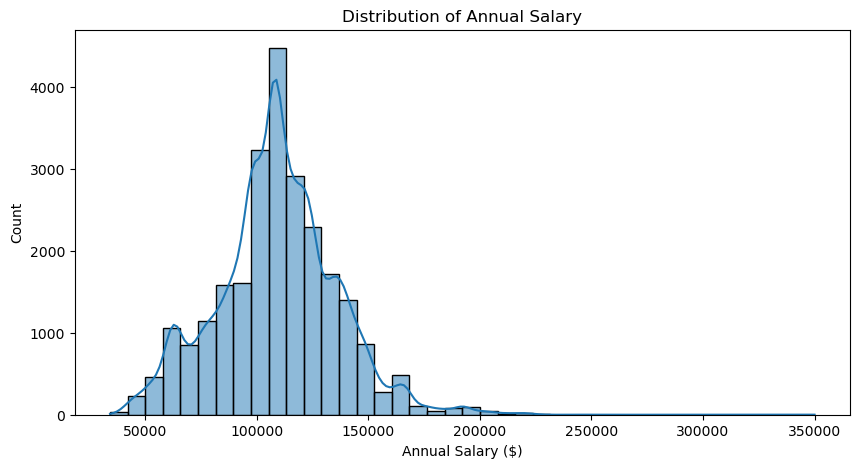

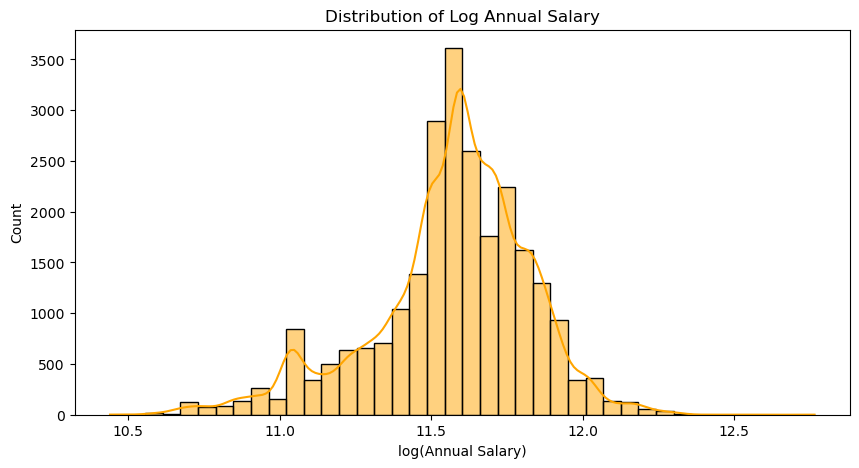

In [13]:
# Distribution of Annual Salary
plt.figure(figsize=(10,5))
sns.histplot(df_salary["annual_salary"], kde=True, bins=40)
plt.title("Distribution of Annual Salary")
plt.xlabel("Annual Salary ($)")
plt.ylabel("Count")
plt.show()

# Distribution of log(Annual Salary)
df_salary["log_salary"] = np.log(df_salary["annual_salary"])

plt.figure(figsize=(10,5))
sns.histplot(df_salary["log_salary"], kde=True, bins=40, color="orange")
plt.title("Distribution of Log Annual Salary")
plt.xlabel("log(Annual Salary)")
plt.ylabel("Count")
plt.show()

<Figure size 600x600 with 0 Axes>

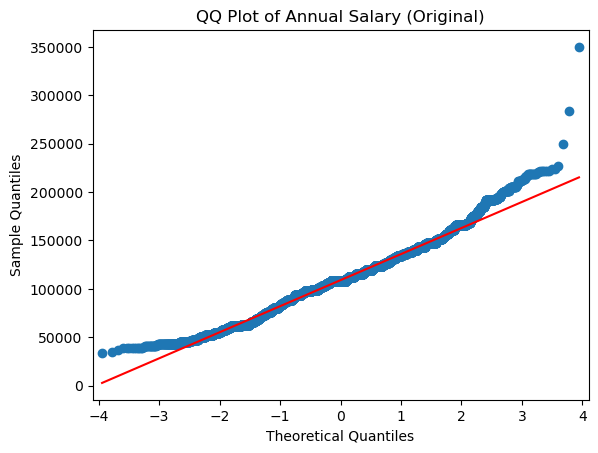

<Figure size 600x600 with 0 Axes>

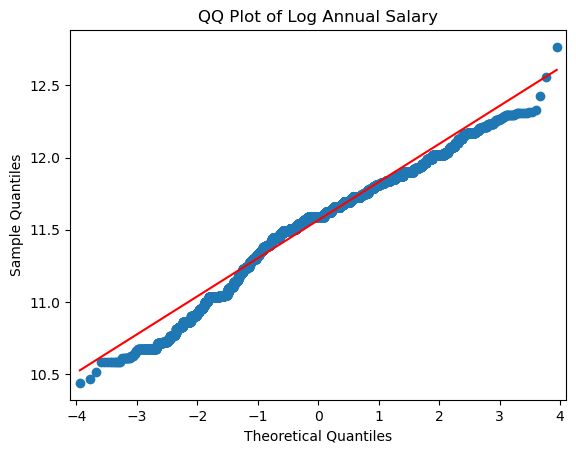

In [17]:
# QQ plot of raw salary
plt.figure(figsize=(6,6))
sm.qqplot(df_salary["annual_salary"], line='s')
plt.title("QQ Plot of Annual Salary (Original)")
plt.show()

# QQ plot of log_salary
plt.figure(figsize=(6,6))
sm.qqplot(df_salary["log_salary"], line='s')
plt.title("QQ Plot of Log Annual Salary")
plt.show()

In [20]:
print(df_salary["annual_salary"].skew())
print(df_salary["log_salary"].skew())

0.2520570824694926
-0.7070522836040186


In [23]:
# Define job-level extraction function
def extract_job_level(title):
    """Extract hierarchical job level from job title using priority rules."""
    
    title_upper = str(title).upper()

    # Roman numeral detection with strict boundaries
    has_V   = bool(re.search(r'\bV\b', title_upper))
    has_IV  = bool(re.search(r'\bIV\b', title_upper))
    has_III = bool(re.search(r'\bIII\b', title_upper))
    has_II  = bool(re.search(r'\bII\b', title_upper))
    has_I   = bool(re.search(r'\bI\b', title_upper))
    
    # Executive level
    if any(word in title_upper for word in ['COMMISSIONER', 'SUPERINTENDENT', 'CHIEF']):
        return 'Executive'
    
    # Senior Management
    elif any(word in title_upper for word in ['DEPUTY', 'ADMINISTRATOR', 'MANAGER',
                                              'CAPTAIN', 'COMMANDER']):
        return 'Senior Management'
    
    # Mid-level Management
    elif any(word in title_upper for word in ['LIEUTENANT', 'SERGEANT', 'SUPERVISOR',
                                              'SUPVSR', 'COORDINATOR']):
        return 'Management'
    
    # Senior Professional (before Roman numerals)
    elif any(word in title_upper for word in ['SENIOR', 'PRINCIPAL', 'LEAD']):
        return 'Senior Professional'
    
    # Professional with Roman numerals
    elif has_V or has_IV:
        return 'Professional V/IV'
    elif has_III or has_II:
        return 'Professional III/II'
    elif has_I:
        return 'Professional I'
    
    # Professional roles
    elif any(word in title_upper for word in ['ANALYST', 'ENGINEER', 'ATTORNEY',
                                              'ARCHITECT', 'ACCOUNTANT', 'INVESTIGATOR',
                                              'SPECIALIST', 'LIBRARIAN', 'PLANNER']):
        return 'Professional'
    
    # Operations / Technical
    elif any(keyword in title_upper for keyword in [
        'POLICE OFFICER', 'SECURITY OFFICER', 'AVIATION OFFICER', 'CORRECTION OFFICER',
        'FIREFIGHTER', 'PARAMEDIC', 'EMT', 'FIRE ENGINEER']):
        return 'Operations/Technical'
    elif any(word in title_upper for word in ['MECHANIC', 'TECHNICIAN', 'OPERATOR',
                                              'ELECTRICIAN', 'PLUMBER']):
        return 'Operations/Technical'
    
    # Administrative / Support
    elif any(word in title_upper for word in ['CLERK', 'ASSISTANT', 'AIDE', 'ASSOCIATE']):
        return 'Administrative/Support'
    
    # Other
    return 'Other'

In [25]:
# Apply job-level extraction & consolidate into 10 levels
# Apply extraction
df_salary['job_level_original'] = df_salary['job_titles'].apply(extract_job_level)

# Mapping to final 10-level hierarchy
merge_mapping = {
    'Executive': 'Executive',
    'Senior Management': 'Senior Management',
    'Management': 'Management',
    'Professional V/IV': 'Professional',
    'Professional': 'Professional',
    'Professional III/II': 'Junior Professional',
    'Professional I': 'Junior Professional',
    'Senior Professional': 'Senior Professional',
    'Operations/Technical': 'Operations/Technical',
    'Administrative/Support': 'Administrative/Support',
    'Other': 'Other'
}

df_salary['job_level'] = df_salary['job_level_original'].map(merge_mapping)
df_salary = df_salary.drop(columns=['job_level_original'])
df_salary.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25009 entries, 0 to 32054
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   job_titles         25009 non-null  object 
 1   department         25009 non-null  object 
 2   full_or_part_time  25009 non-null  object 
 3   annual_salary      25009 non-null  float64
 4   log_salary         25009 non-null  float64
 5   job_level          25009 non-null  object 
dtypes: float64(2), object(4)
memory usage: 1.3+ MB


In [26]:
# Validation summary (salary differences)
level_salary = (
    df_salary.groupby('job_level')
             .agg({'annual_salary': ['mean', 'median', 'count']})
             .round(0)
)

level_salary.columns = ['Mean_Salary', 'Median_Salary', 'Count']
level_salary = level_salary.sort_values('Mean_Salary', ascending=False)

print(level_salary)


                        Mean_Salary  Median_Salary  Count
job_level                                                
Executive                  157746.0       160680.0    735
Management                 136276.0       138510.0   2505
Senior Management          133764.0       136692.0   1026
Operations/Technical       106478.0       108012.0  13215
Other                      105429.0       105372.0   2221
Professional               105315.0       110766.0   1594
Junior Professional         94077.0        94644.0   2040
Senior Professional         92688.0        86640.0    581
Administrative/Support      70651.0        68688.0   1092


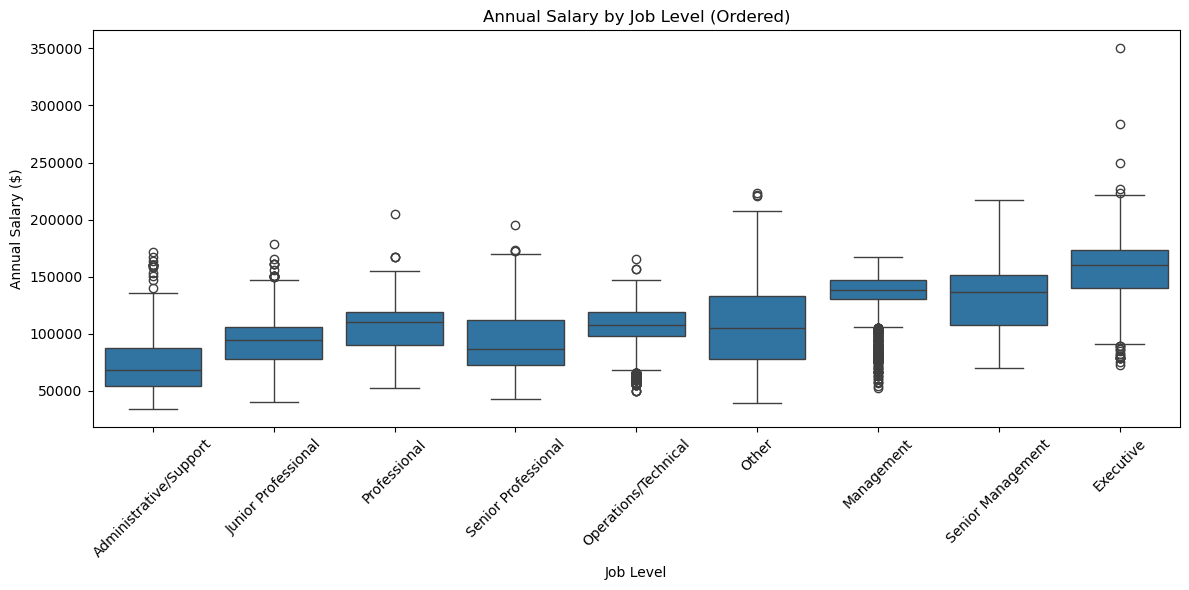

In [82]:
# Boxplot — Salary by Job Level
# Define custom order
job_order = [
    'Administrative/Support',
    'Junior Professional',
    'Professional',
    'Senior Professional',
    'Operations/Technical',
    'Other',
    'Management',
    'Senior Management',
    'Executive'
]

plt.figure(figsize=(12,6))
sns.boxplot(data=df_salary, x='job_level', y='annual_salary', order=job_order)
plt.xticks(rotation=45)
plt.title("Annual Salary by Job Level (Ordered)")
plt.ylabel("Annual Salary ($)")
plt.xlabel("Job Level")
plt.tight_layout()
plt.savefig("boxplot.png")
plt.show()

# Model 1: Baseline model (no interaction)

**Model Formula:** log(salary) ~ department + job_level

In [29]:
model1 = smf.ols(formula="log_salary ~ C(department) + C(job_level)", data=df_salary).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:             log_salary   R-squared:                       0.442
Model:                            OLS   Adj. R-squared:                  0.441
Method:                 Least Squares   F-statistic:                     430.6
Date:                Sun, 23 Nov 2025   Prob (F-statistic):               0.00
Time:                        22:37:41   Log-Likelihood:                 5152.2
No. Observations:               25009   AIC:                        -1.021e+04
Df Residuals:                   24962   BIC:                            -9828.
Df Model:                          46                                         
Covariance Type:            nonrobust                                         
                                                                                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------

# Model 2: with interaction

**Model Formula:**  log(salary) ~ department + job_level + department * job_level

In [32]:
model2 = smf.ols(formula="log_salary ~ C(department) * C(job_level)", data=df_salary).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:             log_salary   R-squared:                       0.519
Model:                            OLS   Adj. R-squared:                  0.514
Method:                 Least Squares   F-statistic:                     99.14
Date:                Sun, 23 Nov 2025   Prob (F-statistic):               0.00
Time:                        22:40:39   Log-Likelihood:                 6992.9
No. Observations:               25009   AIC:                        -1.345e+04
Df Residuals:                   24739   BIC:                        -1.125e+04
Df Model:                         269                                         
Covariance Type:            nonrobust                                         
                                                                                                                      coef    std err          t      P>|t|      [0.025      0.975]
------------------------------

Text(0.5, 1.0, 'Residual vs Fitted Plot')

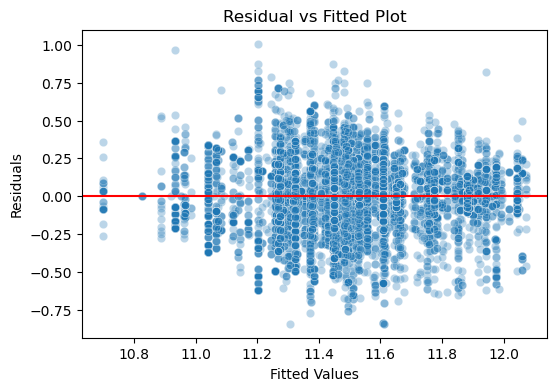

In [38]:
# Model Diagnostics: Residual vs Fitted Plot
residuals = model2.resid
fitted = model2.fittedvalues

plt.figure(figsize=(6,4))
sns.scatterplot(x=fitted, y=residuals, alpha=0.3)
plt.axhline(0, color='red')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residual vs Fitted Plot")

# Compare Models

In [33]:
print("\nMODEL COMPARISON:")
print(f"Model 1 R²:        {model1.rsquared:.4f}")
print(f"Model 1 Adj. R²:   {model1.rsquared_adj:.4f}")
print(f"Model 1 AIC:       {model1.aic:.2f}")
print(f"Model 1 BIC:       {model1.bic:.2f}")

print(f"\nModel 2 R²:        {model2.rsquared:.4f}")
print(f"Model 2 Adj. R²:   {model2.rsquared_adj:.4f}")
print(f"Model 2 AIC:       {model2.aic:.2f}")
print(f"Model 2 BIC:       {model2.bic:.2f}")


MODEL COMPARISON:
Model 1 R²:        0.4424
Model 1 Adj. R²:   0.4414
Model 1 AIC:       -10210.43
Model 1 BIC:       -9828.46

Model 2 R²:        0.5188
Model 2 Adj. R²:   0.5135
Model 2 AIC:       -13445.89
Model 2 BIC:       -11251.60


* Model2 has higher adjusted R^2, lower AIC and BIC -> Model2 is better

In [34]:
from statsmodels.stats.anova import anova_lm

anova_results = anova_lm(model1, model2)
print("\nNESTED MODEL F-TEST:")
print(anova_results)


NESTED MODEL F-TEST:
   df_resid         ssr  df_diff     ss_diff          F  Pr(>F)
0   24962.0  969.795436      0.0         NaN        NaN     NaN
1   24739.0  837.046642    223.0  132.748794  17.593741     0.0


* F >> 0, which means larger model (model 2) is better.
* P-value is close to 0 also means larger model is better.

# Model Results & Interpretation

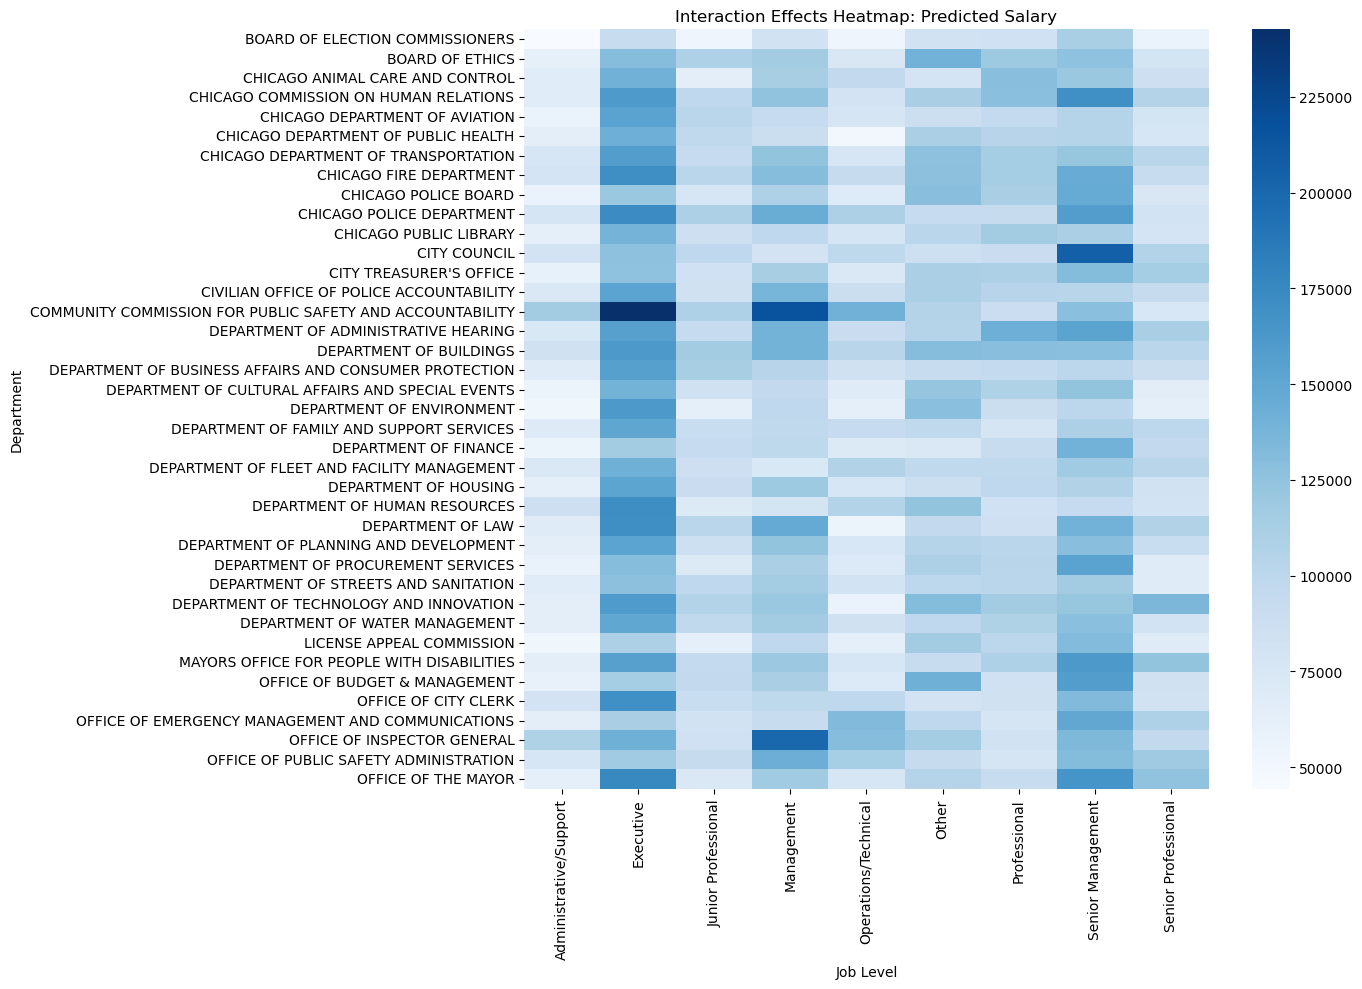

In [58]:
# Interaction Heatmap

# Create combination dataframe
depts = df_salary["department"].unique()
levels = df_salary["job_level"].unique()

combo = pd.MultiIndex.from_product([depts, levels], names=["department", "job_level"]).to_frame(index=False)

# Predict log salary, then convert to dollar salary
combo["predicted_log_salary"] = model2.predict(combo)
combo["predicted_salary"] = combo["predicted_log_salary"].apply(lambda x: round(np.exp(x), 0))

# Pivot table for heatmap
heatmap_df = combo.pivot(index="department", columns="job_level", values="predicted_salary")

plt.figure(figsize=(14, 10))
sns.heatmap(heatmap_df, cmap="Blues", annot=False)
plt.title("Interaction Effects Heatmap: Predicted Salary")
plt.xlabel("Job Level")
plt.ylabel("Department")
plt.tight_layout()
plt.show()

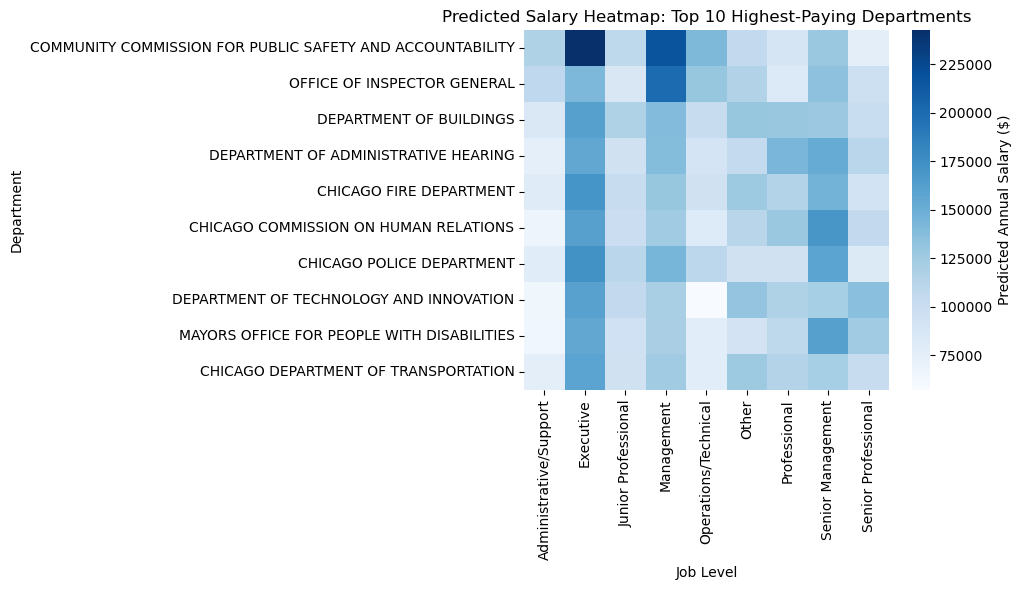

In [80]:
# Top 5 Departments Partial Heatmap

# Compute average predicted salary per department
dept_mean_salary = heatmap_df.mean(axis=1).sort_values(ascending=False)

# Select top 5 highest-paying departments
top10_departments = dept_mean_salary.head(10).index

# Extract subset for heatmap
partial_heatmap = heatmap_df.loc[top10_departments]

plt.figure(figsize=(10, 6))
sns.heatmap(partial_heatmap, cmap="Blues", annot=False, cbar_kws={"label": "Predicted Annual Salary ($)"})
plt.title("Predicted Salary Heatmap: Top 10 Highest-Paying Departments")
plt.xlabel("Job Level")
plt.ylabel("Department")
plt.tight_layout()
plt.savefig("headtmap.png")
plt.show()

In [48]:
# Predicted Salary Table
salary_table = heatmap_df.round(0)
salary_table.head()

job_level,Administrative/Support,Executive,Junior Professional,Management,Operations/Technical,Other,Professional,Senior Management,Senior Professional
department,,,,,,,,,
BOARD OF ELECTION COMMISSIONERS,44340.0,92751.0,53582.0,82949.0,53783.0,83034.0,85176.0,112254.0,57687.0
BOARD OF ETHICS,62061.0,129819.0,108432.0,116099.0,75277.0,139849.0,119216.0,126396.0,80742.0
CHICAGO ANIMAL CARE AND CONTROL,67341.0,140864.0,64080.0,112554.0,96048.0,79856.0,129359.0,120779.0,87611.0
CHICAGO COMMISSION ON HUMAN RELATIONS,66920.0,160893.0,98533.0,125188.0,81170.0,111544.0,128549.0,169416.0,105408.0
CHICAGO DEPARTMENT OF AVIATION,57932.0,153990.0,100894.0,93934.0,78716.0,88074.0,95116.0,104642.0,80444.0


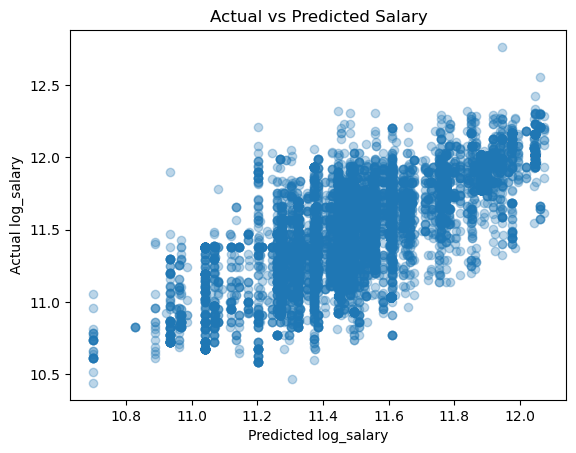

In [71]:
# Model Fit Evaluation: Actual vs Predicted Salary Plot
plt.scatter(model2.fittedvalues, df_salary['log_salary'], alpha=0.3)
plt.xlabel("Predicted log_salary")
plt.ylabel("Actual log_salary")
plt.title("Actual vs Predicted Salary")
plt.show()